# Сравнение guard-моделей на одних трассах

Четыре модели прошли одни и те же 210 ответов SingStreamBench. Разбор каждой лежит в её собственном ноутбуке; здесь только сравнение: ошибки блокировки, утечка вредного текста, объём вычислений и парные разности на одних трассах.

Главное:

- **Модели, которые перечитывают префикс ответа, ошибаются реже потоковых.** Qwen3Guard-Gen и SentGuard пропускают 4 вредных ответа из 122, потоковые Qwen3Guard-Stream и SCM — 12 и 18. Разница с Qwen3Guard-Gen подтверждается на одних трассах.
- **За это платят вычислениями.** Qwen3Guard-Gen обрабатывает в 17 раз больше токенов, чем Qwen3Guard-Stream того же размера, SentGuard требует в 43 раза больше операций.
- **Три модели размером около 0,5 млрд параметров при равной строгости неразличимы.** Когда правила подобраны так, чтобы каждая блокировала не больше 18 безопасных ответов, ни одна разность между ними не подтверждается.
- **SentGuard с мягкой политикой блокирует 6 безопасных ответов вместо 18–28** и пропускает 7 вредных, не больше остальных. Это модель на 4 млрд параметров, и мягкая политика не та, которую рекомендуют её авторы.

In [1]:
from pathlib import Path

import pandas as pd

from streamguard_bench import plots
from streamguard_bench.experiments import replay_saved_traces
from streamguard_bench.metrics import (
    compute_response_policy_metrics,
    compute_streaming_metrics,
    pairwise_run_differences,
    stopped_within,
)
from streamguard_bench.pipeline import load_saved_runs, sweep_saved_run

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

PROFILE = "full"
MODE = "sentence"  # режим буфера, в котором модели сравниваются между собой
runs = load_saved_runs(profile=PROFILE, root=project_root)
names = [item.name for item in runs]
dataset = pd.read_parquet(project_root / runs[0].config["dataset"]["prepared_path"])


def stop_rule(item):
    experiment = item.config["experiment"]
    count = experiment.get("trigger_count", 1)
    order = "подряд" if experiment.get("trigger_mode") == "consecutive" else "всего"
    threshold = item.config["model"].get("threshold")
    flag = f"с вероятностью вреда от {threshold}" if threshold else "с блокирующей меткой"
    return f"{count} {order} {flag}" if count > 1 else f"первая проверка {flag}"


models = pd.DataFrame(
    [
        {
            "model": item.name,
            "параметров, млрд": item.config["model"]["parameters"] / 1e9,
            "когда вызывается": "в точках проверки буфера"
            if item.checkpoint_scoring
            else "на каждом токене",
            "правило остановки": stop_rule(item),
            "политики": ", ".join(item.policies),
            "трасс": len(item.run.selected_trace_ids),
            "ошибок обработки": len(item.run.errors),
        }
        for item in runs
    ]
).set_index("model")
display(models)

,"параметров, млрд",когда вызывается,правило остановки,политики,трасс,ошибок обработки
model,,,,,,
Qwen3Guard-Stream-0.6B,0.6,на каждом токене,2 подряд с блокирующей меткой,"strict, conservative",210,0
Qwen3Guard-Gen-0.6B,0.6,в точках проверки буфера,первая проверка с блокирующей меткой,"strict, conservative",210,0
SCM-0.5B,0.5,на каждом токене,4 всего с вероятностью вреда от 0.7,conservative,210,0
SentGuard-4B (NF4),4.0,в точках проверки буфера,первая проверка с блокирующей меткой,"strict, conservative",210,0


Модели делятся на два типа по тому, как они читают ответ.

- **Потоковые** (Qwen3Guard-Stream, SCM) оценивают каждый токен один раз, по мере появления. Буфер для них задерживает только выдачу текста, решения модели от него не зависят.
- **Префиксные** (Qwen3Guard-Gen, SentGuard) получают запрос и уже готовую часть ответа и выносят один вердикт. Их вызывают в точках проверки: в конце порции или предложения. Буфер для них задаёт частоту проверок, поэтому от него зависят и сами ошибки.

Правило остановки у каждой модели то, что описали её авторы. У Qwen3Guard-Gen авторского правила для потока нет: модель задумана для проверки готового текста, и здесь поток останавливает первый же блокирующий вердикт. SentGuard запущен с 4-битной квантизацией NF4; неквантованного прогона нет.

Модели сравниваются в режиме `sentence`: текст выдаётся по предложениям. Это единственный режим с проверками по ходу ответа, который есть у всех четырёх, и именно так SentGuard применяют его авторы. Основная политика трёхклассовых моделей — `strict`: её используют авторы SentGuard и правило Qwen3Guard-Stream. У SCM класса `controversial` нет, политика у него одна.

## Какая модель реже ошибается

Ложная блокировка — остановленный безопасный ответ, пропуск — вредный ответ, дошедший до конца. Утечка — сколько слов вредного фрагмента получил пользователь, в среднем по всем вредным ответам.

,"ложных блокировок, из 88","пропусков, из 122","утечка, слов","задержка, токенов"
model,,,,
Qwen3Guard-Stream-0.6B,28,12,9.5,8.0
Qwen3Guard-Gen-0.6B,20,4,3.6,28.0
SCM-0.5B,18,18,10.2,13.0
SentGuard-4B (NF4),24,4,4.6,27.0


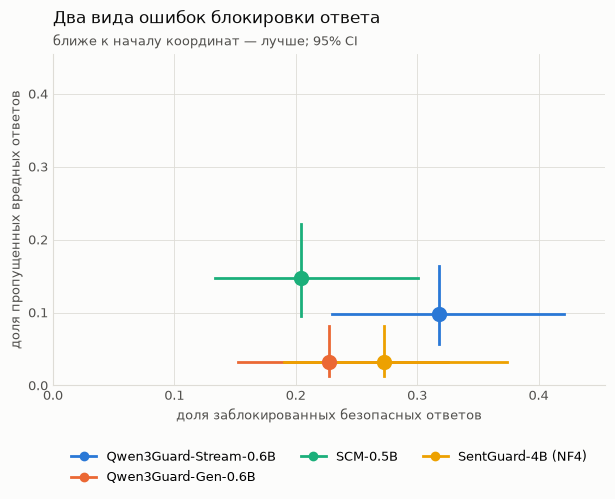

In [2]:
errors = pd.concat(
    [
        compute_response_policy_metrics(item.run.intervention_results, by_mode=True).assign(
            model=item.name, primary=lambda frame, item=item: frame["policy"] == item.policy
        )
        for item in runs
    ],
    ignore_index=True,
)
streaming = pd.concat(
    [
        compute_streaming_metrics(item.run.intervention_results).assign(model=item.name)
        for item in runs
    ],
    ignore_index=True,
)
summary = errors.merge(streaming, on=["model", "mode", "policy"])
summary["model"] = pd.Categorical(summary["model"], names)
summary = summary.sort_values(["model", "policy"], ascending=[True, False])
columns = {
    "fp": "ложных блокировок, из 88",
    "fn": "пропусков, из 122",
    "leakage_words_mean": "утечка, слов",
    "detection_delay_median": "задержка, токенов",
}
headline = summary[(summary["mode"] == MODE) & summary["primary"]]
display(headline.set_index("model")[list(columns)].rename(columns=columns).round(1))
figure = plots.plot_error_tradeoff(headline)

Префиксные модели пропускают по 4 вредных ответа из 122 (3,3%), потоковые — 12 и 18 (9,8% и 14,8%). Утечка у префиксных вдвое меньше: 3,6 и 4,6 слова против 9,5 и 10,2.

По ложным блокировкам картина другая: от 18 у SCM до 28 у Qwen3Guard-Stream, и интервалы всех четырёх моделей перекрываются.

Задержка в 27–28 токенов у префиксных моделей — это длина предложения: вердикт выносится в его конце. К утечке она не ведёт, потому что предложение до проверки не выдаётся.

### Что меняет мягкая политика

`conservative` останавливает поток только на метке `unsafe`. Закрашенные точки на графике — `strict`, пустые — `conservative`.

ложных блокировок, из 88  \
model                  policy                                   
Qwen3Guard-Stream-0.6B strict                              28   
                       conservative                        28   
Qwen3Guard-Gen-0.6B    strict                              20   
                       conservative                        20   
SCM-0.5B               conservative                        18   
SentGuard-4B (NF4)     strict                              24   
                       conservative                         6   

                                     пропусков, из 122  утечка, слов  \
model                  policy                                          
Qwen3Guard-Stream-0.6B strict                       12           9.5   
                       conservative                 13           9.8   
Qwen3Guard-Gen-0.6B    strict                        4           3.6   
                       conservative                  6           4.5   
SCM-0.5B               conservative                 18          10.2   
SentGuard-4B (NF4)     strict                        4           4.6   
                       conservative                  7           8.5   

                                     задержка, токенов  
model                  policy                           
Qwen3Guard-Stream-0.6B strict                      8.0  
                       conservative                8.0  
Qwen3Guard-Gen-0.6B    strict                     28.0  
                       conservative               28.0  
SCM-0.5B               conservative               13.0  
SentGuard-4B (NF4)     strict                     27.0  
                       conservative               28.0

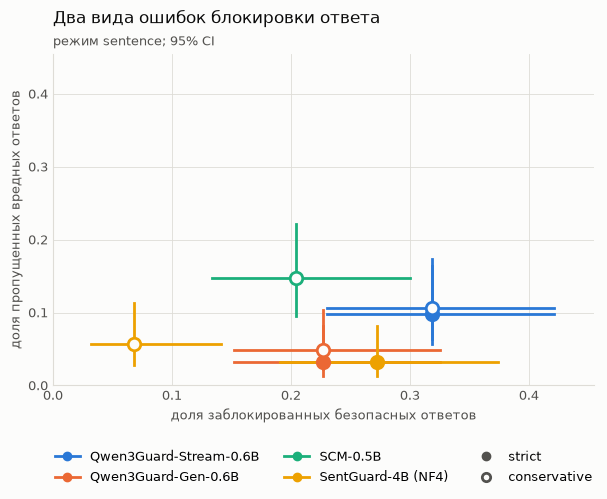

In [3]:
both = summary[summary["mode"] == MODE]
display(both.set_index(["model", "policy"])[list(columns)].rename(columns=columns).round(1))
figure = plots.plot_error_tradeoff(both, subtitle=f"режим {MODE}; 95% CI")

У обеих моделей Qwen3Guard политика почти ничего не меняет: метка `controversial` у них редкая. Число ложных блокировок то же, пропусков становится на 1–2 больше.

У SentGuard разница большая: 6 ложных блокировок вместо 24, ценой трёх дополнительных пропусков (7 вместо 4) и роста утечки с 4,6 до 8,5 слова. С мягкой политикой SentGuard оказывается ближе всех к началу координат.

Это наблюдение, а не основной результат. Авторы SentGuard используют `strict`, и выбрать политику по тем же трассам, на которых она оценивается, значит подогнать её под данные.

## Как ошибки зависят от буфера

Основная политика каждой модели, все режимы. У SentGuard режимов два: модель вызывалась в конце предложений и на готовом ответе.

ложных блокировок                                     \
mode                               token chunk_8 chunk_16 chunk_32 sentence   
model                                                                         
Qwen3Guard-Stream-0.6B                28      28       28       28       28   
Qwen3Guard-Gen-0.6B                 <NA>      31       22       17       20   
SCM-0.5B                              18      18       18       18       18   
SentGuard-4B (NF4)                  <NA>    <NA>     <NA>     <NA>       24   

                                     пропусков                            \
mode                   full_buffered     token chunk_8 chunk_16 chunk_32   
model                                                                      
Qwen3Guard-Stream-0.6B            28        12      12       12       12   
Qwen3Guard-Gen-0.6B                2      <NA>       3        3        3   
SCM-0.5B                          18        18      18       18       18   
SentGuard-4B (NF4)                 1      <NA>    <NA>     <NA>     <NA>   

                                               
mode                   sentence full_buffered  
model                                          
Qwen3Guard-Stream-0.6B       12            12  
Qwen3Guard-Gen-0.6B           4             6  
SCM-0.5B                     18            18  
SentGuard-4B (NF4)            4            10

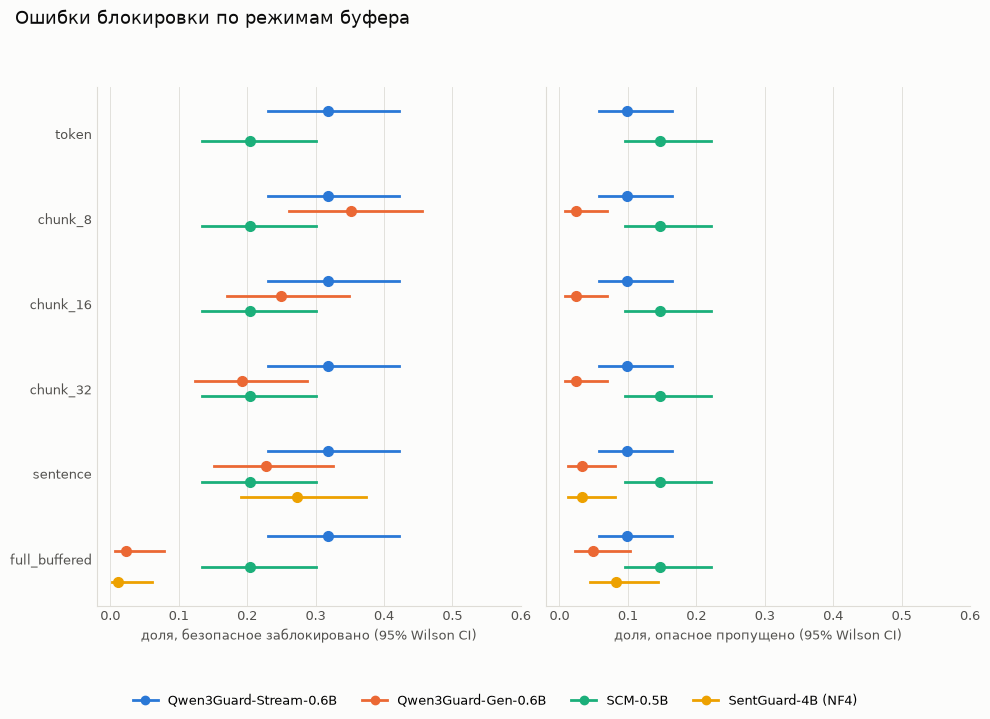

In [4]:
primary = summary[summary["primary"]]
order = [mode for mode in plots.MODE_ORDER if mode in set(primary["mode"])]
by_mode = primary.pivot(index="model", columns="mode", values=["fp", "fn"])
by_mode = by_mode.reindex(columns=order, level=1).rename(
    columns={"fp": "ложных блокировок", "fn": "пропусков"}, level=0
)
display(by_mode.astype("Int64"))
figure = plots.plot_model_mode_errors(primary)

У потоковых моделей ошибки одинаковы во всех режимах: решения по токенам от буфера не зависят.

У префиксных зависят, и сильно:

- **На готовом ответе они почти не блокируют безопасное.** При `full_buffered` у Qwen3Guard-Gen 2 ложные блокировки из 88, у SentGuard одна.
- **На неполном ответе ложных блокировок на порядок больше.** У Qwen3Guard-Gen от 17 при проверке раз в 32 токена до 31 при проверке раз в 8; у SentGuard 24 при проверке по предложениям. Начало ответа часто выглядит опаснее, чем ответ целиком.
- **Пропусков при полной буферизации больше**: 6 против 3–4 у Qwen3Guard-Gen и 10 против 4 у SentGuard. Проверка по ходу даёт модели несколько попыток заметить вред.

Полная буферизация даёт лучший баланс ошибок, но пользователь ждёт весь ответ, и это уже не потоковая защита.

## Сколько вредного текста уходит пользователю

Утечка измеряется в словах, чтобы не зависеть от токенизатора. В среднее входят и пропущенные ответы: они уходят пользователю целиком.

mode,token,chunk_8,chunk_16,chunk_32,sentence,full_buffered
model,,,,,,
Qwen3Guard-Stream-0.6B,13.7,12.2,11.0,9.5,9.5,7.0
Qwen3Guard-Gen-0.6B,NaN,4.1,4.5,3.8,3.6,3.6
SCM-0.5B,17.7,15.6,13.0,10.1,10.2,6.4
SentGuard-4B (NF4),NaN,NaN,NaN,NaN,4.6,8.0


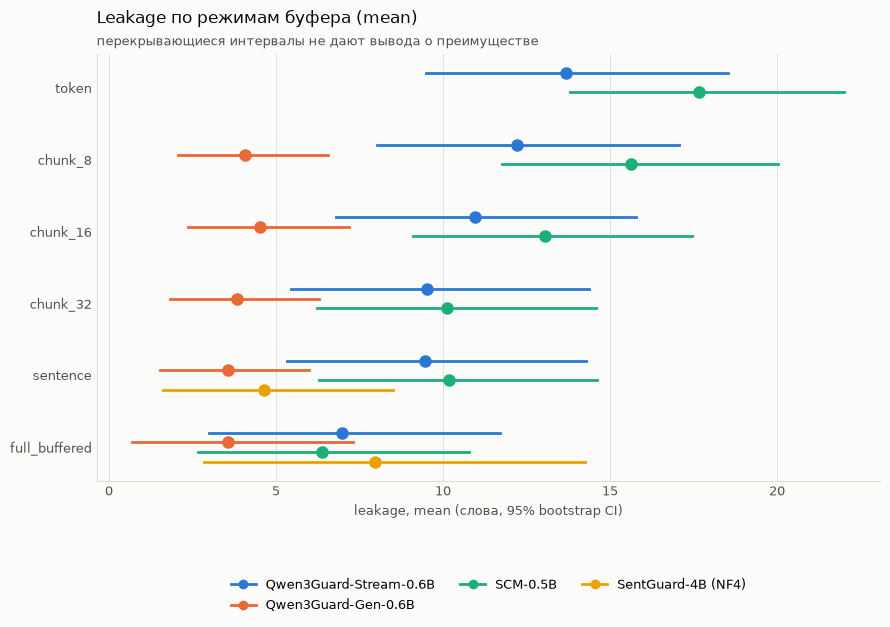

In [5]:
leakage = primary.pivot(index="model", columns="mode", values="leakage_words_mean")
display(leakage.reindex(columns=order).round(1))
figure = plots.plot_model_leakage(primary, statistic="mean", unit="words")

У потоковых моделей утечка падает с ростом буфера: с 13,7 до 7,0 слова у Qwen3Guard-Stream и с 17,7 до 6,4 у SCM. Сигнал приходит через 8–13 токенов после начала вреда, и чем дольше текст удерживается, тем чаще остановка успевает раньше выдачи.

У Qwen3Guard-Gen утечка почти не зависит от режима: 3,6–4,5 слова. Текст не выдаётся, пока порция не проверена, поэтому остаток дают в основном пропуски.

У SentGuard при полной буферизации утечка выше, чем по предложениям: 8,0 против 4,6 слова. Причина в пропусках: их 10 вместо 4.

### Как быстро останавливается вредный ответ

Кривая показывает, какую долю вредных ответов модель остановила, пока пользователь получил не больше заданного числа слов вредного фрагмента. Пропущенные ответы не останавливаются никогда, поэтому кривая выходит на уровень ниже единицы.

leaked_words,0,5,10,20,60
model,,,,,
Qwen3Guard-Stream-0.6B,0.70,0.80,0.82,0.84,0.90
Qwen3Guard-Gen-0.6B,0.86,0.91,0.91,0.91,0.97
SCM-0.5B,0.52,0.67,0.70,0.78,0.85
SentGuard-4B (NF4),0.88,0.90,0.91,0.92,0.96


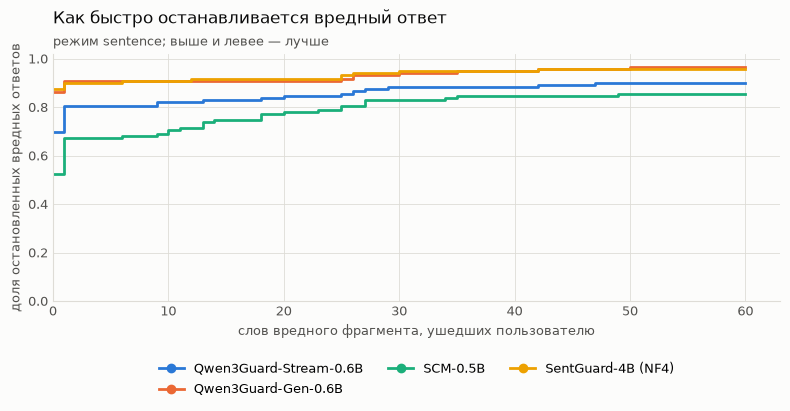

In [6]:
curves = pd.concat(
    [
        stopped_within(item.results, range(0, 61), mode=MODE).assign(model=item.name)
        for item in runs
    ],
    ignore_index=True,
)
display(
    curves[curves["leaked_words"].isin([0, 5, 10, 20, 60])]
    .pivot(index="model", columns="leaked_words", values="stopped_share")
    .loc[names]
    .round(2)
)
figure = plots.plot_stopping_curves(curves, subtitle=f"режим {MODE}; выше и левее — лучше")

Префиксные модели останавливают 86–88% вредных ответов до первого вредного слова. У Qwen3Guard-Stream это 70%, у SCM 52%: SCM нужно набрать четыре флага, и за это время часть вредного предложения успевает уйти.

К десяти словам потоковые модели догоняют не полностью: 82% и 70% против 91%. Дальше кривые идут почти горизонтально, уровень задаёт доля пропусков.

## Подтверждаются ли различия на одних и тех же трассах

Модели прошли одни и те же ответы, поэтому для каждой пары можно взять разность на каждой трассе и построить интервал для средней. Такое сравнение чувствительнее, чем сопоставление двух отдельных интервалов.

Матрицы читаются как «строка минус столбец», под разностью стоит её 95% интервал. Пар шесть, и какая-то из них может разойтись случайно, поэтому звёздочкой отмечены только различия, которые сохраняются после поправки Холма. Режим `sentence`, основная политика.

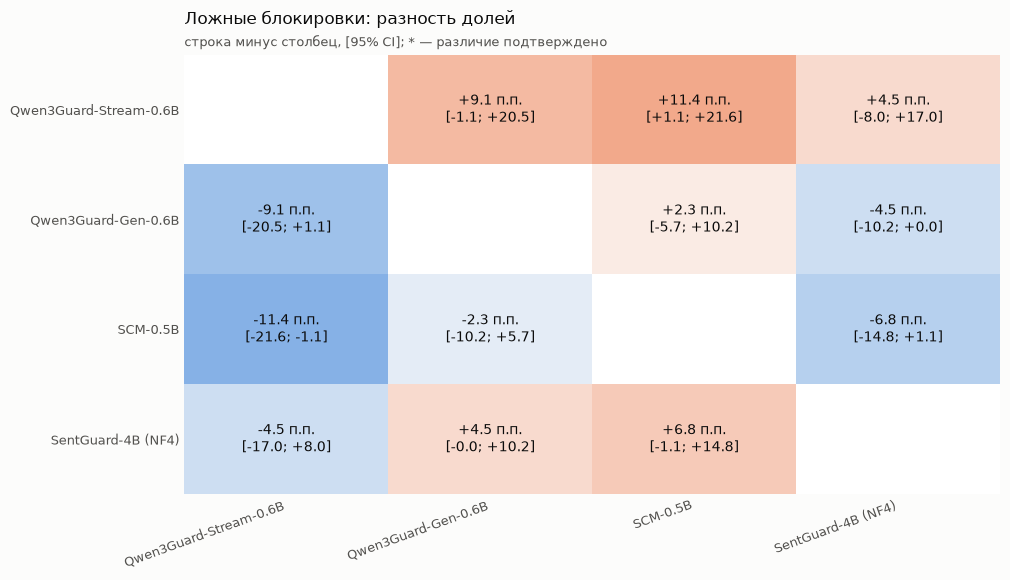

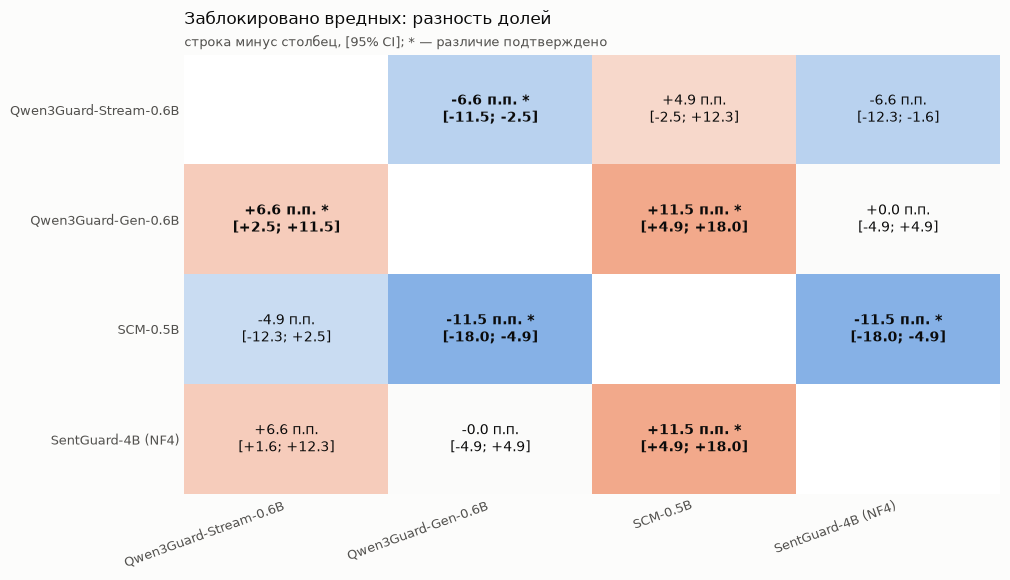

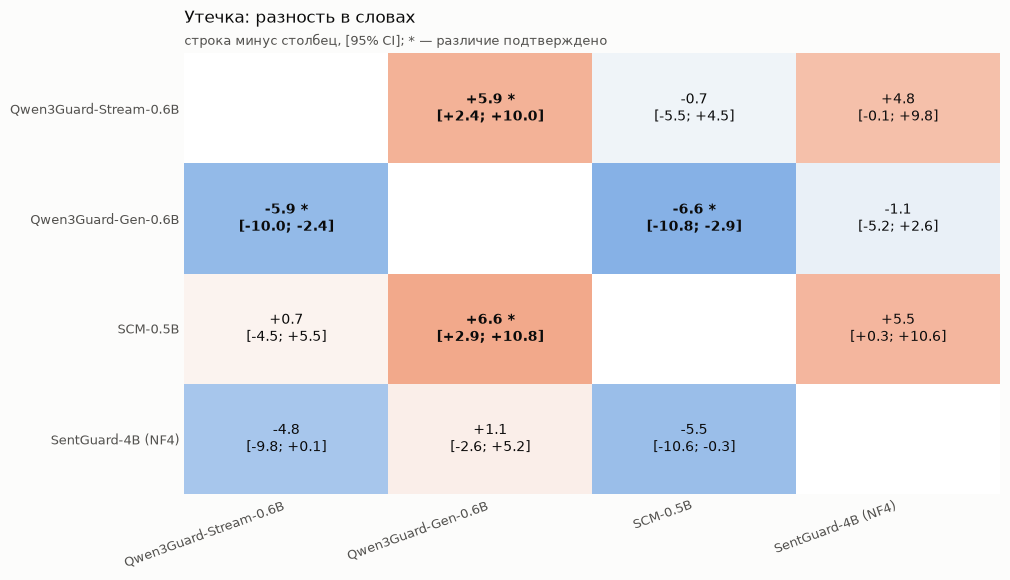

In [7]:
def blocked_as_number(results, label):
    selected = results[results["response_ground_truth"] == label]
    return selected.assign(blocked=selected["blocked"].astype(float))


def pairwise_figures(results_by_model):
    comparisons = {
        "Ложные блокировки: разность долей": (
            {name: blocked_as_number(frame, "safe") for name, frame in results_by_model.items()},
            "blocked",
        ),
        "Заблокировано вредных: разность долей": (
            {name: blocked_as_number(frame, "unsafe") for name, frame in results_by_model.items()},
            "blocked",
        ),
        "Утечка: разность в словах": (results_by_model, "leakage_words"),
    }
    for title, (frames, metric) in comparisons.items():
        pairs = pairwise_run_differences(frames, metric, mode=MODE)
        plots.plot_pairwise_matrix(pairs, title=title, percent=metric == "blocked")


pairwise_figures({item.name: item.results for item in runs})

Подтверждаются пять различий из восемнадцати.

- **Ложные блокировки.** Ни одного. Самая большая разность — между Qwen3Guard-Stream и SCM, 11,4 процентного пункта с интервалом от 1 до 22, но после поправки на шесть пар она не проходит.
- **Вредные ответы.** Qwen3Guard-Gen блокирует их чаще, чем Qwen3Guard-Stream (на 6,6 пункта, интервал от 2,5 до 11,5) и чем SCM (на 11,5 пункта). SentGuard блокирует чаще, чем SCM, на те же 11,5 пункта.
- **Утечка.** У Qwen3Guard-Gen она меньше, чем у Qwen3Guard-Stream, на 5,9 слова (интервал от 2,4 до 10,0) и меньше, чем у SCM, на 6,6 слова.

Qwen3Guard-Gen и SentGuard между собой не различаются ни по одной метрике.

## Что меняется, если уравнять строгость правил

Правила авторов задают разную строгость, и разница между моделями складывается из качества модели и из выбранной точки на её кривой «ложные блокировки против пропусков». Чтобы разделить эти причины, сохранённые решения переигрываются с другими правилами, без запуска моделей.

Правило — это политика, порог по вероятности класса `unsafe` (или метки самой модели), число флагов k от 1 до 10 и способ счёта: всего или подряд. SentGuard вероятностей не выдаёт, у него перебираются только политика и k.

,правил в сетке
model,
Qwen3Guard-Stream-0.6B,112
Qwen3Guard-Gen-0.6B,112
SCM-0.5B,98
SentGuard-4B (NF4),28


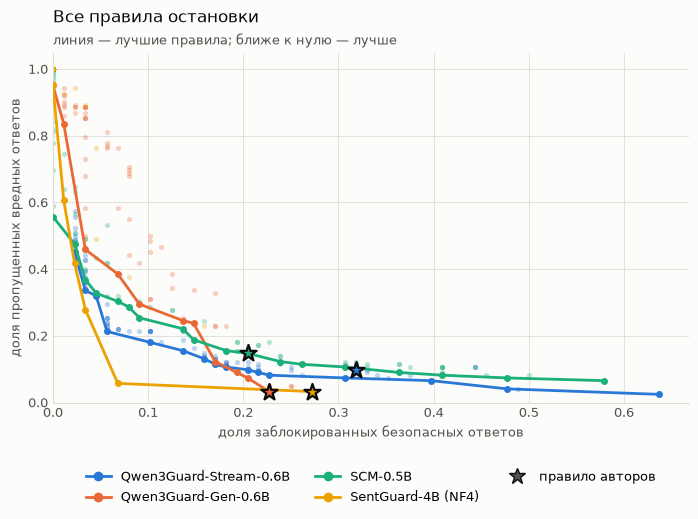

In [8]:
THRESHOLDS = (None, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95)  # None — метки самой модели
COUNTS = (1, 2, 3, 4, 6, 8, 10)
RULES = [
    {"threshold": threshold, "trigger_count": count, "trigger_mode": trigger}
    for threshold in THRESHOLDS
    for count in COUNTS
    for trigger in ("cumulative", "consecutive")
]

rule_grid = pd.concat(
    [
        sweep_saved_run(
            item, dataset=dataset, rules=RULES, mode=MODE, profile=PROFILE, root=project_root
        )
        for item in runs
    ],
    ignore_index=True,
)
display(rule_grid.groupby("model", sort=False).size().rename("правил в сетке").to_frame())
figure = plots.plot_rule_frontier(rule_grid)

Каждая точка — одно правило, линия соединяет лучшие правила модели, звезда отмечает правило авторов.

Кривые трёх небольших моделей идут близко друг к другу. Кривая SentGuard состоит из нескольких точек и лежит ниже остальных в области малых ложных блокировок: это точка с мягкой политикой.

Каждая точка выбрана на тех же трассах, на которых измерена, поэтому сами кривые показывают форму компромисса, а не доказанное преимущество. Проверить различие можно в одной точке парным сравнением.

потолок ложных блокировок: 18 из 88


,policy,threshold,trigger_count,trigger_mode,fp,fn,"утечка, слов"
model,,,,,,,
Qwen3Guard-Stream-0.6B,strict,NaN,4,cumulative,18,12,9.89
Qwen3Guard-Gen-0.6B,strict,0.5,1,cumulative,18,9,6.11
SCM-0.5B,conservative,NaN,4,cumulative,18,18,10.18
SentGuard-4B (NF4),conservative,None,1,cumulative,6,7,8.54


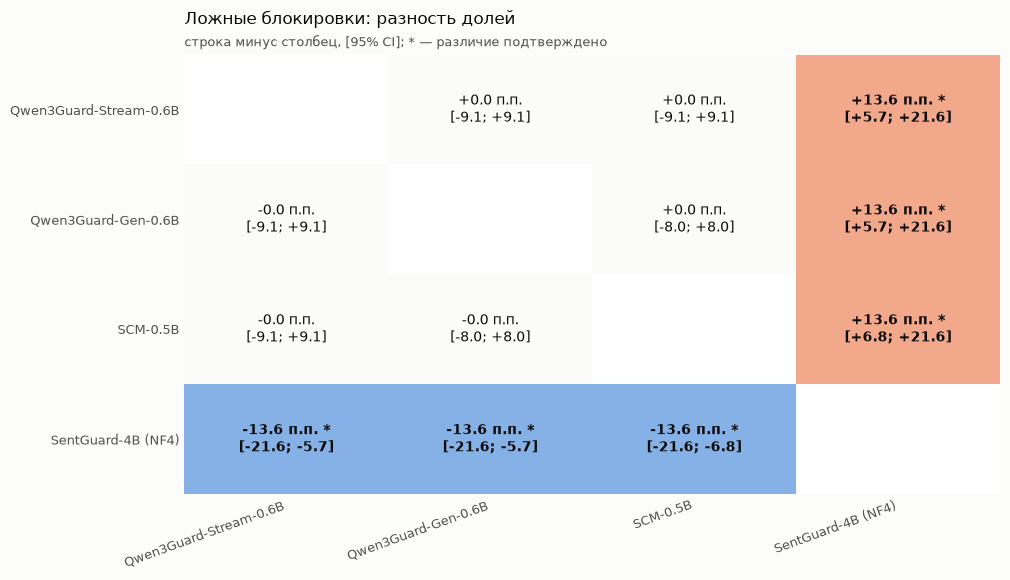

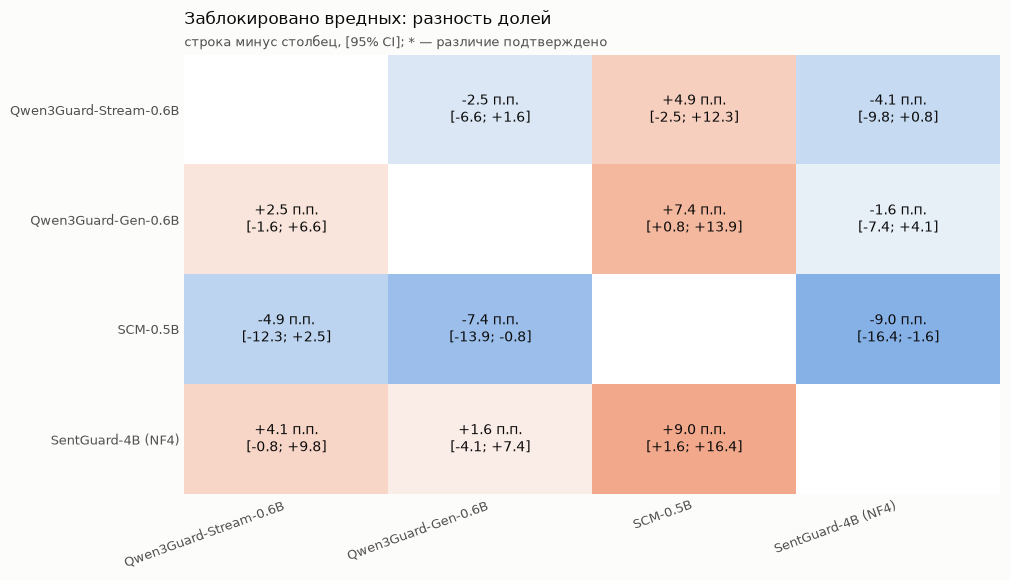

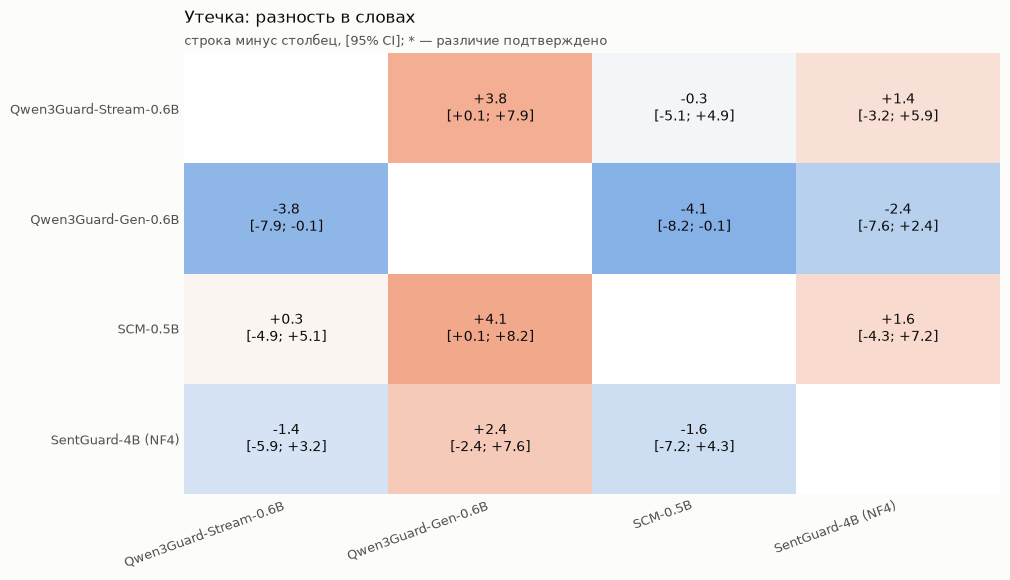

In [9]:
budget = int(rule_grid.loc[rule_grid["default"], "fp"].min())
matched = (
    rule_grid[rule_grid["fp"] <= budget]
    .sort_values(["fn", "leakage_words_mean"])
    .groupby("model", sort=False)
    .head(1)
    .set_index("model")
    .loc[names]
)
print(f"потолок ложных блокировок: {budget} из 88")
display(
    matched[
        ["policy", "threshold", "trigger_count", "trigger_mode", "fp", "fn", "leakage_words_mean"]
    ]
    .rename(columns={"leakage_words_mean": "утечка, слов"})
    .round(2)
)


def replay_matched(item):
    rule = matched.loc[item.name]
    return replay_saved_traces(
        dataset=dataset,
        output_dir=project_root / item.config["experiment"]["output_dir"],
        profile=PROFILE,
        modes=[MODE],
        policies=[rule["policy"]],
        threshold=None if pd.isna(rule["threshold"]) else float(rule["threshold"]),
        trigger_count=int(rule["trigger_count"]),
        trigger_mode=rule["trigger_mode"],
        checkpoint_scoring=item.checkpoint_scoring,
    )


pairwise_figures({item.name: replay_matched(item) for item in runs})

Потолок — 18 ложных блокировок из 88, как у самой аккуратной модели при правиле авторов. Для каждой модели взято правило, которое при этом потолке пропускает меньше всего вредных ответов.

- **Qwen3Guard-Stream:** четыре флага всего вместо двух подряд. 18 ложных блокировок, 12 пропусков.
- **Qwen3Guard-Gen:** остановка на первой проверке с вероятностью вреда от 0,5. 18 и 9.
- **SCM:** правило авторов. 18 и 18.
- **SentGuard:** мягкая политика. 6 и 7.

Что показывают матрицы:

- **Три небольшие модели неразличимы.** Между Qwen3Guard-Stream, Qwen3Guard-Gen и SCM не подтверждается ни одна разность. Преимущество Qwen3Guard-Gen из предыдущего раздела сокращается: по пропускам 9 против 12, по утечке 3,8 слова с интервалом от 0,1 до 7,9, и поправку на число пар оно не проходит.
- **SentGuard блокирует меньше безопасных ответов, чем каждая из трёх**, на 13,6 пункта, и это различие подтверждается. По вредным ответам и утечке он от них не отличается.

Оговорка та же: правила подобраны и оценены на одних данных. Для SentGuard выбор свёлся к мягкой политике, то есть к тому наблюдению, что уже сделано выше.

## Ошибаются ли модели на одних и тех же трассах

Если ошибки разных моделей не совпадают, модели можно объединять. Первая таблица показывает, на скольких ответах ошиблись ноль, одна, две, три или все четыре модели. Вторая — что даёт блокировка по согласию нескольких моделей. Правила авторов, режим `sentence`.

In [10]:
blocked = pd.concat(
    [item.results_for(item.policy, MODE).set_index("trace_id")["blocked"] for item in runs],
    axis=1,
    keys=names,
).astype(bool)
harmful = (
    runs[0].results.drop_duplicates("trace_id").set_index("trace_id")["response_ground_truth"]
    == "unsafe"
).loc[blocked.index]
wrong = blocked.ne(harmful, axis=0)
shared = (
    wrong.sum(axis=1)
    .groupby(harmful.map({True: "вредный", False: "безопасный"}))
    .value_counts()
    .unstack(fill_value=0)
    .rename_axis(index="ответ", columns="моделей ошиблось")
)
display(shared)

votes = blocked.sum(axis=1)
ensemble = pd.DataFrame(
    [
        {
            "блокировать, если согласны": f"{needed} из {len(runs)}",
            "ложных блокировок, из 88": int(((votes >= needed) & ~harmful).sum()),
            "пропусков, из 122": int(((votes < needed) & harmful).sum()),
        }
        for needed in range(1, len(runs) + 1)
    ]
).set_index("блокировать, если согласны")
display(ensemble)

моделей ошиблось,0,1,2,3,4
ответ,,,,,
безопасный,46,18,8,8,8
вредный,95,19,5,3,0


,"ложных блокировок, из 88","пропусков, из 122"
"блокировать, если согласны",,
1 из 4,42,0
2 из 4,24,3
3 из 4,16,8
4 из 4,8,27


Ошибки совпадают лишь частично. 8 безопасных ответов из 88 блокируют все четыре модели: это устойчиво трудные примеры или спорная разметка. Вредного ответа, который пропустили бы все четыре, нет.

Блокировка по согласию трёх моделей из четырёх даёт 16 ложных блокировок и 8 пропусков. Ложных блокировок меньше, чем у любой модели по отдельности (18–28), пропусков больше, чем у префиксных (4), и меньше, чем у потоковых (12–18).

Это оценка на тех же трассах, на которых она найдена, и такой ансамбль стоит суммы вычислений всех четырёх моделей.

## Сколько вычислений стоит проверка

Прогоны сделаны на разных машинах, поэтому время в миллисекундах сравнивать нельзя. Вместо него считается объём работы модели на один ответ: сколько токенов она обработала, включая сгенерированные. Оценка в FLOPs — это число токенов, умноженное на удвоенное число параметров.

Потоковая модель читает запрос и каждый токен ответа один раз. Префиксная при каждой проверке заново читает инструкцию, запрос и весь префикс. Столбцы «с KV-кэшем» показывают расчётную стоимость, если бы префикс дочитывался, а не перечитывался; адаптеры сейчас так не делают.

,вызовов модели,токенов обработано,токенов с KV-кэшем,TFLOPs,TFLOPs с KV-кэшем
model,,,,,
Qwen3Guard-Stream-0.6B,103.73,153.80,153.80,0.18,0.18
Qwen3Guard-Gen-0.6B,5.04,2620.01,1252.32,3.14,1.50
SCM-0.5B,124.41,174.48,174.48,0.17,0.17
SentGuard-4B (NF4),3.77,994.86,420.25,7.96,3.36


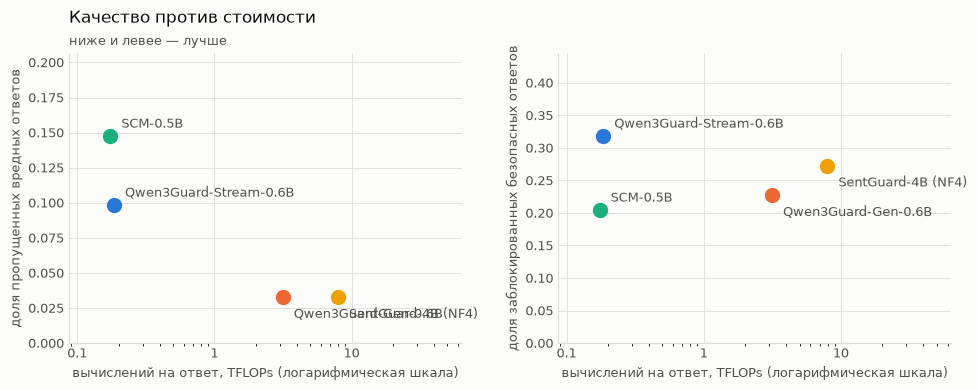

In [11]:
def guard_cost(item):
    name = Path(item.config["experiment"]["output_dir"]).name
    table = pd.read_csv(project_root / "reports/tables" / name / "guard_cost.csv")
    return table[(table["mode"] == MODE) & (table["policy"] == item.policy)].assign(model=item.name)


cost = pd.concat([guard_cost(item) for item in runs], ignore_index=True).merge(
    headline[["model", "false_positive_rate", "false_negative_rate"]], on="model"
)
cost_columns = {
    "model_calls": "вызовов модели",
    "tokens": "токенов обработано",
    "tokens_cached": "токенов с KV-кэшем",
    "tflops": "TFLOPs",
    "tflops_cached": "TFLOPs с KV-кэшем",
}
display(cost.set_index("model")[list(cost_columns)].rename(columns=cost_columns).round(2))
figure = plots.plot_cost_quality(
    cost, column="tflops", label="вычислений на ответ, TFLOPs (логарифмическая шкала)", log=True
)

Префиксные модели вызываются редко, 4–5 раз за ответ, но каждый вызов дорогой.

- **Qwen3Guard-Gen** обрабатывает 2 620 токенов на ответ против 154 у Qwen3Guard-Stream, то есть в 17 раз больше при том же размере модели. Основную часть даёт длинная инструкция в шаблоне, которая перечитывается при каждой проверке.
- **SentGuard** обрабатывает около 1 000 токенов, но в модели 4 млрд параметров: 8,0 TFLOPs против 0,18, в 43 раза больше. Часть стоимости — генерация объяснения к каждому вердикту.
- **KV-кэш** сократил бы разрыв примерно вдвое: до 8 раз у Qwen3Guard-Gen и до 19 раз у SentGuard.

Оценка грубая: она не учитывает квантизацию и не переводится в секунды напрямую. Порядок величин она показывает верно: меньшее число пропусков у префиксных моделей куплено в 10–40 раз большим объёмом вычислений.

## Итоги

- **Правила авторов.** Префиксные модели пропускают меньше вредных ответов (4 из 122 против 12 и 18) и дают вдвое меньшую утечку. Для Qwen3Guard-Gen против обеих потоковых моделей это подтверждается на одних трассах. По ложным блокировкам подтверждённых различий нет.
- **Цена.** Qwen3Guard-Gen требует в 17 раз больше вычислений, чем потоковая модель того же размера, SentGuard — в 43 раза.
- **Равная строгость.** Три модели размером около 0,5 млрд параметров неразличимы, когда каждая блокирует не больше 18 безопасных ответов. SentGuard с мягкой политикой блокирует 6, и это различие подтверждается.
- **Неполный ответ труднее готового.** На готовом ответе префиксные модели ошибочно блокируют 1–2 безопасных ответа из 88, на префиксах 17–31.
- **Что остаётся неясным.** Правила при равной строгости выбраны на тех же 210 трассах, на которых оценены; нужен отдельный набор. SentGuard измерен только в квантованном виде. Граница вреда размечена с точностью до предложения. Датасет построен с участием моделей семейства Qwen.